In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Verify your data is accessible
import os
COCO_DIR = '/content/drive/MyDrive/license-plate-detection/coco'
print('Annotations:', os.listdir(os.path.join(COCO_DIR, 'annotations')))
print('Images:', os.listdir(os.path.join(COCO_DIR, 'images')))

Mounted at /content/drive
Annotations: ['instances_val.json', 'instances_train.json', 'instances_test.json']
Images: ['test', 'train', 'val']


In [2]:
!pip install pycocotools torchvision torch

import torch
print(f"GPU: {torch.cuda.is_available()} - {torch.cuda.get_device_name(0)}")

GPU: True - Tesla T4


In [3]:
import os
import json
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from copy import deepcopy

import torch
import torchvision
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn_v2,
    retinanet_resnet50_fpn_v2,
    FasterRCNN_ResNet50_FPN_V2_Weights,
    RetinaNet_ResNet50_FPN_V2_Weights
)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.retinanet import RetinaNetClassificationHead
from torch.utils.data import Dataset, DataLoader
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# Paths
COCO_DIR = '/content/drive/MyDrive/license-plate-detection/coco'
ANNOT_DIR = os.path.join(COCO_DIR, 'annotations')
IMAGE_DIR = os.path.join(COCO_DIR, 'images')

# Training config
NUM_CLASSES = 2  # background + licence
NUM_EPOCHS = 50
BATCH_SIZE = 4
LEARNING_RATE = 0.005
PATIENCE = 10

# Output directories
RESULTS_DIR = '/content/drive/MyDrive/license-plate-detection/results'
MODELS_DIR = '/content/drive/MyDrive/license-plate-detection/models'
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print("Config ready!")

Using device: cuda
Config ready!


In [4]:
class LicensePlateDataset(Dataset):
    """COCO format dataset for license plate detection."""

    def __init__(self, annotation_file, image_dir, transforms=None):
        self.coco = COCO(annotation_file)
        self.image_dir = image_dir
        self.transforms = transforms
        self.ids = list(self.coco.imgs.keys())

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.image_dir, img_info['file_name'])
        img = Image.open(img_path).convert('RGB')

        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)

        boxes = []
        labels = []
        areas = []

        for ann in anns:
            x, y, w, h = ann['bbox']
            if w > 0 and h > 0:
                boxes.append([x, y, x + w, y + h])
                labels.append(ann['category_id'])
                areas.append(ann['area'])

        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            areas = torch.zeros((0,), dtype=torch.float32)
        else:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
            areas = torch.as_tensor(areas, dtype=torch.float32)

        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([img_id]),
            'area': areas,
            'iscrowd': torch.zeros((len(boxes),), dtype=torch.int64)
        }

        img = torchvision.transforms.functional.to_tensor(img)

        return img, target

# Create datasets
train_dataset = LicensePlateDataset(
    os.path.join(ANNOT_DIR, 'instances_train.json'),
    os.path.join(IMAGE_DIR, 'train')
)
val_dataset = LicensePlateDataset(
    os.path.join(ANNOT_DIR, 'instances_val.json'),
    os.path.join(IMAGE_DIR, 'val')
)
test_dataset = LicensePlateDataset(
    os.path.join(ANNOT_DIR, 'instances_test.json'),
    os.path.join(IMAGE_DIR, 'test')
)

def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Train: {len(train_dataset)} images")
print(f"Val:   {len(val_dataset)} images")
print(f"Test:  {len(test_dataset)} images")

loading annotations into memory...
Done (t=0.42s)
creating index...
index created!
loading annotations into memory...
Done (t=0.40s)
creating index...
index created!
loading annotations into memory...
Done (t=0.37s)
creating index...
index created!
Train: 302 images
Val:   64 images
Test:  67 images


In [5]:
def train_model(model, model_name, train_loader, val_loader, num_epochs, patience, lr):
    """Train a detection model with early stopping."""

    model.to(DEVICE)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=0.0005)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

    train_losses = []
    best_loss = float('inf')
    patience_counter = 0
    best_model_state = None
    start_time = time.time()

    for epoch in range(num_epochs):
        # --- Training ---
        model.train()
        epoch_loss = 0

        for images, targets in train_loader:
            images = [img.to(DEVICE) for img in images]
            targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

            optimizer.zero_grad()
            losses.backward()
            optimizer.step()

            epoch_loss += losses.item()

        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)
        scheduler.step(avg_loss)

        # --- Early stopping check ---
        if avg_loss < best_loss:
            best_loss = avg_loss
            patience_counter = 0
            best_model_state = deepcopy(model.state_dict())
        else:
            patience_counter += 1

        if (epoch + 1) % 5 == 0 or epoch == 0:
            elapsed = time.time() - start_time
            print(f"Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f} | Best: {best_loss:.4f} | Time: {elapsed/60:.1f}min")

        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
            break

    total_time = time.time() - start_time
    print(f"\n{model_name} training complete in {total_time/60:.1f} minutes")

    # Load best weights
    model.load_state_dict(best_model_state)

    # Save model
    save_path = os.path.join(MODELS_DIR, f'{model_name}_best.pt')
    torch.save(best_model_state, save_path)
    print(f"Model saved to {save_path}")

    return model, train_losses, total_time

In [6]:
@torch.no_grad()
def evaluate_model(model, data_loader, annotation_file, model_name, split_name):
    """Evaluate using COCO metrics."""

    model.eval()
    model.to(DEVICE)

    coco_gt = COCO(annotation_file)
    results = []
    inference_times = []

    for images, targets in data_loader:
        images = [img.to(DEVICE) for img in images]

        start = time.time()
        outputs = model(images)
        inference_times.append((time.time() - start) / len(images))

        for output, target in zip(outputs, targets):
            img_id = target['image_id'].item()
            boxes = output['boxes'].cpu().numpy()
            scores = output['scores'].cpu().numpy()
            labels = output['labels'].cpu().numpy()

            for box, score, label in zip(boxes, scores, labels):
                x1, y1, x2, y2 = box
                results.append({
                    'image_id': img_id,
                    'category_id': int(label),
                    'bbox': [float(x1), float(y1), float(x2 - x1), float(y2 - y1)],
                    'score': float(score)
                })

    avg_inference = np.mean(inference_times) * 1000  # ms per image
    fps = 1000 / avg_inference if avg_inference > 0 else 0

    if len(results) == 0:
        print(f"{model_name} ({split_name}): No detections!")
        return {'mAP50': 0, 'mAP50_95': 0, 'precision': 0, 'recall': 0, 'fps': fps, 'inference_ms': avg_inference}

    # Save results and evaluate
    results_file = f'/content/{model_name}_{split_name}_results.json'
    with open(results_file, 'w') as f:
        json.dump(results, f)

    coco_dt = coco_gt.loadRes(results_file)
    coco_eval = COCOeval(coco_gt, coco_dt, 'bbox')
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    metrics = {
        'mAP50_95': coco_eval.stats[0],
        'mAP50': coco_eval.stats[1],
        'fps': fps,
        'inference_ms': avg_inference
    }

    print(f"\n{model_name} ({split_name}):")
    print(f"  mAP@50:    {metrics['mAP50']:.4f}")
    print(f"  mAP@50:95: {metrics['mAP50_95']:.4f}")
    print(f"  FPS:       {fps:.1f}")
    print(f"  Inference: {avg_inference:.1f}ms per image")

    return metrics

In [7]:
print("=" * 60)
print("TRAINING FASTER R-CNN")
print("=" * 60)

# Load pretrained Faster R-CNN
frcnn_model = fasterrcnn_resnet50_fpn_v2(weights=FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT)

# Replace head for our number of classes
in_features = frcnn_model.roi_heads.box_predictor.cls_score.in_features
frcnn_model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)

# Train
frcnn_model, frcnn_losses, frcnn_time = train_model(
    frcnn_model, 'faster_rcnn', train_loader, val_loader,
    NUM_EPOCHS, PATIENCE, LEARNING_RATE
)

TRAINING FASTER R-CNN
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:01<00:00, 149MB/s]


Epoch 1/50 | Loss: 0.1781 | Best: 0.1781 | Time: 3.9min
Epoch 5/50 | Loss: 0.0526 | Best: 0.0526 | Time: 13.4min
Epoch 10/50 | Loss: 0.0359 | Best: 0.0359 | Time: 25.2min
Epoch 15/50 | Loss: 0.0317 | Best: 0.0317 | Time: 37.1min
Epoch 20/50 | Loss: 0.0280 | Best: 0.0270 | Time: 49.0min
Epoch 25/50 | Loss: 0.0242 | Best: 0.0242 | Time: 60.9min
Epoch 30/50 | Loss: 0.0210 | Best: 0.0210 | Time: 72.7min
Epoch 35/50 | Loss: 0.0211 | Best: 0.0207 | Time: 84.6min
Epoch 40/50 | Loss: 0.0177 | Best: 0.0177 | Time: 96.4min
Epoch 45/50 | Loss: 0.0169 | Best: 0.0169 | Time: 108.3min
Epoch 50/50 | Loss: 0.0163 | Best: 0.0163 | Time: 120.2min

faster_rcnn training complete in 120.2 minutes
Model saved to /content/drive/MyDrive/license-plate-detection/models/faster_rcnn_best.pt


In [8]:
print("\n" + "=" * 60)
print("EVALUATING FASTER R-CNN")
print("=" * 60)

frcnn_val_metrics = evaluate_model(
    frcnn_model, val_loader,
    os.path.join(ANNOT_DIR, 'instances_val.json'),
    'faster_rcnn', 'val'
)

frcnn_test_metrics = evaluate_model(
    frcnn_model, test_loader,
    os.path.join(ANNOT_DIR, 'instances_test.json'),
    'faster_rcnn', 'test'
)


EVALUATING FASTER R-CNN
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.02s).
Accumulating evaluation results...
DONE (t=0.01s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.519
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.977
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.528
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.419
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.595
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.536
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.599
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.625
 Average Recall     (AR) @[ IoU=0.50:0.9

In [10]:
print("=" * 60)
print("TRAINING RETINANET")
print("=" * 60)

# Load pretrained RetinaNet
retinanet_model = retinanet_resnet50_fpn_v2(weights=RetinaNet_ResNet50_FPN_V2_Weights.DEFAULT)

# Replace classification head for our number of classes
num_anchors = retinanet_model.head.classification_head.num_anchors
in_channels = retinanet_model.backbone.out_channels
retinanet_model.head.classification_head = RetinaNetClassificationHead(
    in_channels=in_channels,
    num_anchors=num_anchors,
    num_classes=NUM_CLASSES
)

# Train with LOWER learning rate for RetinaNet
retinanet_model, retinanet_losses, retinanet_time = train_model(
    retinanet_model, 'retinanet', train_loader, val_loader,
    NUM_EPOCHS, PATIENCE, 0.001  # Lower LR: 0.001 instead of 0.005
)

TRAINING RETINANET
Epoch 1/50 | Loss: 1.3902 | Best: 1.3902 | Time: 1.7min
Epoch 5/50 | Loss: 1.2458 | Best: 1.0547 | Time: 8.6min
Epoch 10/50 | Loss: 1.2457 | Best: 0.8627 | Time: 17.2min
Epoch 15/50 | Loss: 0.4406 | Best: 0.4406 | Time: 25.8min
Epoch 20/50 | Loss: 0.2550 | Best: 0.2550 | Time: 34.4min
Epoch 25/50 | Loss: 0.1911 | Best: 0.1911 | Time: 42.9min
Epoch 30/50 | Loss: 0.1724 | Best: 0.1724 | Time: 51.5min
Epoch 35/50 | Loss: 0.1356 | Best: 0.1356 | Time: 60.1min
Epoch 40/50 | Loss: 0.1266 | Best: 0.1257 | Time: 68.7min
Epoch 45/50 | Loss: 0.1173 | Best: 0.1161 | Time: 77.3min
Epoch 50/50 | Loss: 0.1097 | Best: 0.1097 | Time: 85.9min

retinanet training complete in 85.9 minutes
Model saved to /content/drive/MyDrive/license-plate-detection/models/retinanet_best.pt


In [11]:
print("\n" + "=" * 60)
print("EVALUATING RETINANET")
print("=" * 60)

retinanet_val_metrics = evaluate_model(
    retinanet_model, val_loader,
    os.path.join(ANNOT_DIR, 'instances_val.json'),
    'retinanet', 'val'
)

retinanet_test_metrics = evaluate_model(
    retinanet_model, test_loader,
    os.path.join(ANNOT_DIR, 'instances_test.json'),
    'retinanet', 'test'
)


EVALUATING RETINANET
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.02s).
Accumulating evaluation results...
DONE (t=0.01s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.516
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.958
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.528
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.417
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.580
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.525
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.578
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.609
 Average Recall     (AR) @[ IoU=0.50:0.95 |

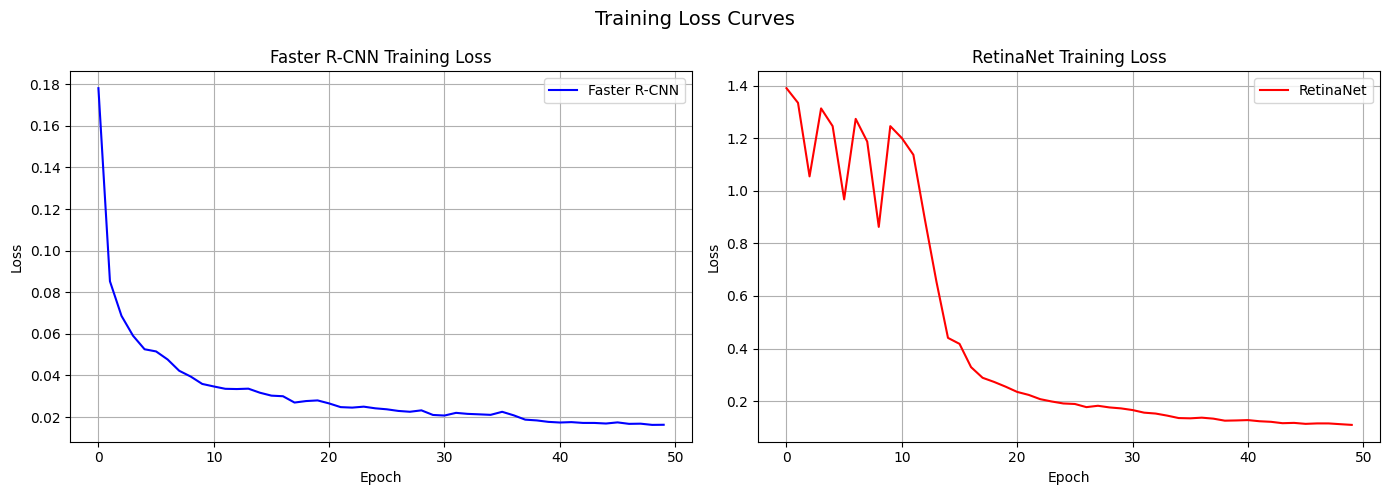

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(frcnn_losses, label='Faster R-CNN', color='blue')
axes[0].set_title('Faster R-CNN Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(retinanet_losses, label='RetinaNet', color='red')
axes[1].set_title('RetinaNet Training Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Training Loss Curves', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'frcnn_retinanet_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

In [13]:
import pandas as pd

comparison = {
    'Model': ['Faster R-CNN', 'RetinaNet'],
    'mAP@50 (test)': [frcnn_test_metrics['mAP50'], retinanet_test_metrics['mAP50']],
    'mAP@50:95 (test)': [frcnn_test_metrics['mAP50_95'], retinanet_test_metrics['mAP50_95']],
    'FPS': [frcnn_test_metrics['fps'], retinanet_test_metrics['fps']],
    'Inference (ms)': [frcnn_test_metrics['inference_ms'], retinanet_test_metrics['inference_ms']],
    'Training Time (min)': [frcnn_time/60, retinanet_time/60]
}

df_compare = pd.DataFrame(comparison)
print("\n" + "=" * 60)
print("FASTER R-CNN vs RETINANET COMPARISON")
print("=" * 60)
print(df_compare.to_string(index=False))

# Save results
df_compare.to_csv(os.path.join(RESULTS_DIR, 'frcnn_retinanet_comparison.csv'), index=False)
print(f"\nResults saved to {RESULTS_DIR}")

print("\n" + "=" * 60)
print("PHASE 4 COMPLETE!")
print("=" * 60)


FASTER R-CNN vs RETINANET COMPARISON
       Model  mAP@50 (test)  mAP@50:95 (test)     FPS  Inference (ms)  Training Time (min)
Faster R-CNN       0.906604          0.532457 5.09364      196.323239           120.214416
   RetinaNet       0.892469          0.505681 7.89926      126.594130            85.864538

Results saved to /content/drive/MyDrive/license-plate-detection/results

PHASE 4 COMPLETE!
